# Pattern Recognition and removal of rows 

In [46]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# Set pandas options to avoid truncation of rows and columns
pd.set_option('display.max_rows', None)       # Show all rows
pd.set_option('display.max_columns', None)    # Show all columns
pd.set_option('display.width', None)          # Adjust the display width dynamically
pd.set_option('display.max_colwidth', None)   # Prevent truncation of cell content

In [47]:
# import data
file_path = 'all_answers.csv'

df = pd.read_csv(file_path)

df.columns

Index(['id', 'second', 'PC', 'console', 'mobile', 'hours', 'CS', 'DOTA', 'FN',
       'LOL', 'VAL', 'noGame', 'participation', 'leftGroup', 'gamerIdentity',
       'trollingThrowingSeverity', 'leavingSeverity', 'nameCallingSeverity',
       'sexMesSeverity', 'patronizingSeverity', 'flirtingSeverity',
       'doxxingSeverity', 'microAgressionSeverity', 'senseOfBelonging',
       'moreWorkWelcome', 'discouraging', 'welcomingSpace', 'avoidCommunities',
       'reportingMe', 'reportingOther', 'mutingTeamVoice', 'mutingTeamText',
       'mutingVoicePlayer', 'mutingTextPlayer', 'mutingAllVoice',
       'mutingAllText', 'joinBanter', 'ignoreStatement', 'upsetsMe',
       'notPhased', 'upsetAfterPlaying', 'supportVictim', 'noActionUntilBad',
       'ex1Sev(1)', 'ex1Real(1)', 'ex2Sev(3)', 'ex2Real(3)', 'ex3Sev(3)',
       'ex3Real(3)', 'ex4Sev(4)', 'ex4Real(4)', 'ex5Sev(4)', 'ex5Real(4)',
       'ex6Sev(5)', 'ex6Real(5)', 'ex7Sev(5)', 'ex7Real(5)', 'ex8Sev(6)',
       'ex8Real(6)', 'ex9Sev(6)',

## Filter out responses

In [48]:
df['VAL'].value_counts()

VAL
1    172
0    103
Name: count, dtype: int64

### Straight-lining / Pattern Responses

In [ ]:
# Check for missing values
def is_nan_row(row, columns):
    values = row[columns]
    # If all values are NaN, consider it "okay"
    if values.isna().all():
        return True  # No pattern problem if skipped
    return False

# Check for line patterns
def is_straight_line(row, columns):
    if (is_nan_row(row, columns)):
        return False
    return row[columns].nunique() == 1

# Check for increasing or decreasing patterns
def is_increasing_or_decreasing(row, columns):
    if (is_nan_row(row, columns)):
        return False
    values = row[columns].astype(float).values
    diffs = np.diff(values)
    return np.all(diffs == 1) or np.all(diffs == -1)

# Check for alternating patterns
def is_alternating(row, columns):
    if (is_nan_row(row, columns)):
        return False
    values = row[columns].astype(float).values
    
    # Check if there are exactly 2 unique values
    unique_values = np.unique(values)
    if len(unique_values) != 2:
        return False
    
    # Check if the pattern is alternating
    for i in range(2, len(values)):
        if values[i] != values[i - 2]:  # Compare with the value two steps before
            return False
    return True

# Check for repeating blocks
def is_repeating_block(row, columns):
    if (is_nan_row(row, columns)):
        return False
    values = row[columns].astype(float).tolist()
    if len(values) % 2 != 0:
        return False
    half = len(values) // 2
    return values[:half] * 2 == values



Severity of Examples

In [52]:
sev_columns = ['ex1Sev(1)', 'ex2Sev(3)', 'ex3Sev(3)', 'ex4Sev(4)', 'ex5Sev(4)',
       'ex6Sev(5)', 'ex7Sev(5)', 'ex8Sev(6)', 'ex9Sev(6)', 'ex10Sev(7)',
       'ex11Sev(7)', 'ex12Sev(kit)',
       'ex13Sev(ski)', 'ex14Sev(spe)']

df['straight_line_flag_severity'] = df.apply(is_straight_line, columns=sev_columns, axis=1)
df['diagonal_pattern_flag_severity'] = df.apply(is_increasing_or_decreasing, columns=sev_columns, axis=1)
df['alternating_pattern_flag_severity'] = df.apply(is_alternating, columns=sev_columns, axis=1)
df['repeating_block_flag_severity'] = df.apply(is_repeating_block, columns=sev_columns, axis=1)

# Combine into one 'pattern_response_flag_severity'
df['pattern_response_flag_severity'] = df[['straight_line_flag_severity', 'diagonal_pattern_flag_severity', 'alternating_pattern_flag_severity', 'repeating_block_flag_severity']].any(axis=1)
df.loc[df['pattern_response_flag_severity'], sev_columns]

,ex1Sev(1),ex2Sev(3),ex3Sev(3),ex4Sev(4),ex5Sev(4),ex6Sev(5),ex7Sev(5),ex8Sev(6),ex9Sev(6),ex10Sev(7),ex11Sev(7),ex12Sev(kit),ex13Sev(ski),ex14Sev(spe)
178,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
250,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0


Realness of the quotes

In [53]:
truth_columns = ['ex1Real(1)', 'ex2Real(3)',
       'ex3Real(3)', 'ex4Real(4)', 'ex5Real(4)',
        'ex6Real(5)', 'ex7Real(5)',
       'ex8Real(6)', 'ex9Real(6)', 'ex10Real(7)',
       'ex11Real(7)','ex12Real(kit)',
       'ex13Real(ski)','ex14Real(spe)',]

df['pattern_response_flag_truth'] = df.apply(is_straight_line, columns=truth_columns, axis=1)

# Combine into one 'pattern_response_flag_truth'
df.loc[df['pattern_response_flag_truth'], truth_columns].value_counts()

ex1Real(1)  ex2Real(3)  ex3Real(3)  ex4Real(4)  ex5Real(4)  ex6Real(5)  ex7Real(5)  ex8Real(6)  ex9Real(6)  ex10Real(7)  ex11Real(7)  ex12Real(kit)  ex13Real(ski)  ex14Real(spe)
1.0         1.0         1.0         1.0         1.0         1.0         1.0         1.0         1.0         1.0          1.0          1.0            1.0            1.0              60
Name: count, dtype: int64

Severity of Types of Gendered Discrimination

In [54]:
types_column = ['trollingThrowingSeverity', 'leavingSeverity', 'nameCallingSeverity', 'sexMesSeverity', 'patronizingSeverity', 'flirtingSeverity', 'doxxingSeverity', 'microAgressionSeverity']

df['straight_line_flag_type'] = df.apply(is_straight_line, columns=types_column, axis=1)
df['diagonal_pattern_flag_type'] = df.apply(is_increasing_or_decreasing, columns=types_column, axis=1)
df['alternating_pattern_flag_type'] = df.apply(is_alternating, columns=types_column, axis=1)
df['repeating_block_flag_type'] = df.apply(is_repeating_block, columns=types_column, axis=1)

# Combine into one 'pattern_response_flag_type'
df['pattern_response_flag_type'] = df[['straight_line_flag_type', 'diagonal_pattern_flag_type', 'alternating_pattern_flag_type', 'repeating_block_flag_type']].any(axis=1)
df.loc[df['pattern_response_flag_type'], types_column]


,trollingThrowingSeverity,leavingSeverity,nameCallingSeverity,sexMesSeverity,patronizingSeverity,flirtingSeverity,doxxingSeverity,microAgressionSeverity
0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0
25,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0
32,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0
45,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0
73,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
131,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0
161,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0
164,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0
178,1.0,1.0,2.0,1.0,1.0,1.0,2.0,1.0
188,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0


Likert Scales 

In [55]:
likert_column = ['senseOfBelonging',
       'moreWorkWelcome', 'discouraging', 'welcomingSpace', 'avoidCommunities']

df['straight_line_flag_likert'] = df.apply(is_straight_line, columns=likert_column, axis=1)
df['diagonal_pattern_flag_likert'] = df.apply(is_increasing_or_decreasing, columns=likert_column, axis=1)
df['alternating_pattern_flag_likert'] = df.apply(is_alternating, columns=likert_column, axis=1)
df['repeating_block_flag_likert'] = df.apply(is_repeating_block, columns=likert_column, axis=1)

# Combine into one 'pattern_response_flag_likert'
df['pattern_response_flag_likert'] = df[['straight_line_flag_likert', 'diagonal_pattern_flag_likert', 'alternating_pattern_flag_likert', 'repeating_block_flag_likert']].any(axis=1)
df.loc[df['pattern_response_flag_likert'], likert_column]

,senseOfBelonging,moreWorkWelcome,discouraging,welcomingSpace,avoidCommunities
68,2.0,4.0,2.0,4.0,2.0
72,4.0,3.0,4.0,3.0,4.0
73,1.0,1.0,1.0,1.0,1.0
205,3.0,3.0,3.0,3.0,3.0


Used ingame mechanics

In [56]:
mech_column = ['reportingMe', 'reportingOther', 'mutingTeamVoice', 'mutingTeamText',
       'mutingVoicePlayer', 'mutingTextPlayer', 'mutingAllVoice',
       'mutingAllText']

df['straight_line_flag_mech'] = df.apply(is_straight_line, columns=mech_column, axis=1)
df['diagonal_pattern_flag_mech'] = df.apply(is_increasing_or_decreasing, columns=mech_column, axis=1)
df['alternating_pattern_flag_mech'] = df.apply(is_alternating, columns=mech_column, axis=1)
df['repeating_block_flag_mech'] = df.apply(is_repeating_block, columns=mech_column, axis=1)

# Combine into one 'pattern_response_flag_mech'
df['pattern_response_flag_mech'] = df[['straight_line_flag_mech', 'diagonal_pattern_flag_mech', 'alternating_pattern_flag_mech', 'repeating_block_flag_mech']].any(axis=1)
df.loc[df['pattern_response_flag_mech'], mech_column]

,reportingMe,reportingOther,mutingTeamVoice,mutingTeamText,mutingVoicePlayer,mutingTextPlayer,mutingAllVoice,mutingAllText
9,4.0,4.0,2.0,2.0,4.0,4.0,2.0,2.0
25,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
42,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
47,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
49,2.0,2.0,1.0,1.0,2.0,2.0,1.0,1.0
50,5.0,5.0,2.0,2.0,5.0,5.0,2.0,2.0
73,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
89,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
95,5.0,5.0,2.0,2.0,5.0,5.0,2.0,2.0
102,5.0,5.0,3.0,3.0,5.0,5.0,3.0,3.0


Matrix Question ''Someone in my team makes a sexist statement... '' 

In [57]:
statement_column = ['joinBanter', 'ignoreStatement', 'upsetsMe',
       'notPhased', 'upsetAfterPlaying', 'supportVictim', 'noActionUntilBad']

df['straight_line_flag_statement'] = df.apply(is_straight_line, columns=statement_column, axis=1)
df['diagonal_pattern_flag_statement'] = df.apply(is_increasing_or_decreasing, columns=statement_column, axis=1)
df['alternating_pattern_flag_statement'] = df.apply(is_alternating, columns=statement_column, axis=1)
df['repeating_block_flag_statement'] = df.apply(is_repeating_block, columns=statement_column, axis=1)

# Combine into one 'pattern_response_flag_statement'
df['pattern_response_flag_statement'] = df[['straight_line_flag_statement', 'diagonal_pattern_flag_statement', 'alternating_pattern_flag_statement', 'repeating_block_flag_statement']].any(axis=1)
df.loc[df['pattern_response_flag_statement'], statement_column]

,joinBanter,ignoreStatement,upsetsMe,notPhased,upsetAfterPlaying,supportVictim,noActionUntilBad
73,1.0,1.0,1.0,1.0,1.0,1.0,1.0


No Games: can probably be ignored, since we did not ask for those in case someone had done the survey before already.

In [58]:
games_column = ['second', 'CS', 'DOTA', 'VAL', 'FN',
       'LOL', 'noGame']

# It doesn't make sense to check for repeating block patterns in this case
df['pattern_response_flag_games'] = df.apply(is_straight_line, columns=games_column, axis=1)

df.loc[df['pattern_response_flag_games'], games_column]

,second,CS,DOTA,VAL,FN,LOL,noGame


# Filtering Rules 

Pattern Response Flags: 

pattern_response_flag_games

pattern_response_flag_statement

pattern_response_flag_mech

pattern_response_flag_likert

pattern_response_flag_type

pattern_response_flag_truth

pattern_response_flag_severity

Filter out all rows with 3 out of 7 flags 

In [59]:
df['pattern_count'] = df[[
    'pattern_response_flag_games',
    'pattern_response_flag_statement',
    'pattern_response_flag_mech',
    'pattern_response_flag_likert',
    'pattern_response_flag_type',
    'pattern_response_flag_truth',
    'pattern_response_flag_severity'
]].sum(axis=1)

df_cleaned = df[df['pattern_count'] < 3]



<Axes: ylabel='Frequency'>

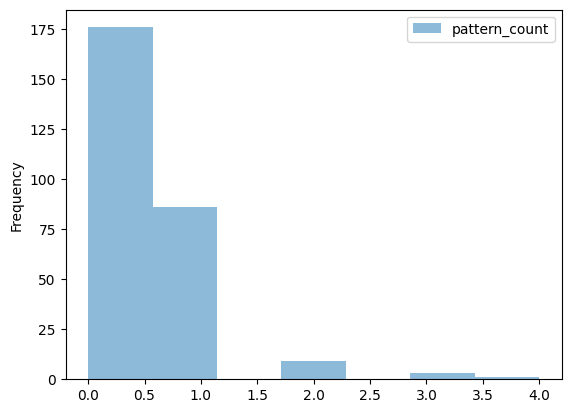

In [60]:
df.plot.hist(y='pattern_count', bins=7, alpha=0.5)

In [61]:
df_2 = df[df['pattern_count'] == 4]

In [62]:
df_2

,id,second,PC,console,mobile,hours,CS,DOTA,FN,LOL,VAL,noGame,participation,leftGroup,gamerIdentity,trollingThrowingSeverity,leavingSeverity,nameCallingSeverity,sexMesSeverity,patronizingSeverity,flirtingSeverity,doxxingSeverity,microAgressionSeverity,senseOfBelonging,moreWorkWelcome,discouraging,welcomingSpace,avoidCommunities,reportingMe,reportingOther,mutingTeamVoice,mutingTeamText,mutingVoicePlayer,mutingTextPlayer,mutingAllVoice,mutingAllText,joinBanter,ignoreStatement,upsetsMe,notPhased,upsetAfterPlaying,supportVictim,noActionUntilBad,ex1Sev(1),ex1Real(1),ex2Sev(3),ex2Real(3),ex3Sev(3),ex3Real(3),ex4Sev(4),ex4Real(4),ex5Sev(4),ex5Real(4),ex6Sev(5),ex6Real(5),ex7Sev(5),ex7Real(5),ex8Sev(6),ex8Real(6),ex9Sev(6),ex9Real(6),ex10Sev(7),ex10Real(7),ex11Sev(7),ex11Real(7),ex12Sev(kit),ex12Real(kit),ex13Sev(ski),ex13Real(ski),ex14Sev(spe),ex14Real(spe),gender,genderOther,age,EU,ASIA,SA,NA,AFR,OCE,straight_line_flag_severity,diagonal_pattern_flag_severity,alternating_pattern_flag_severity,repeating_block_flag_severity,pattern_response_flag_severity,pattern_response_flag_truth,straight_line_flag_type,diagonal_pattern_flag_type,alternating_pattern_flag_type,repeating_block_flag_type,pattern_response_flag_type,straight_line_flag_likert,diagonal_pattern_flag_likert,alternating_pattern_flag_likert,repeating_block_flag_likert,pattern_response_flag_likert,straight_line_flag_mech,diagonal_pattern_flag_mech,alternating_pattern_flag_mech,repeating_block_flag_mech,pattern_response_flag_mech,straight_line_flag_statement,diagonal_pattern_flag_statement,alternating_pattern_flag_statement,repeating_block_flag_statement,pattern_response_flag_statement,pattern_response_flag_games,pattern_count
73,102,0,0,1,0.0,10-20,0,0,1,0,0,0,Active,1.0,Strongly,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,False,False,False,False,False,False,True,False,False,True,True,True,False,False,False,True,True,False,False,True,True,True,False,False,False,True,False,4


In [66]:
df_cleaned = df_cleaned.drop(['straight_line_flag_severity',
       'diagonal_pattern_flag_severity', 'alternating_pattern_flag_severity',
       'repeating_block_flag_severity', 'pattern_response_flag_severity',
       'straight_line_flag_type', 'diagonal_pattern_flag_type',
       'alternating_pattern_flag_type', 'repeating_block_flag_type',
       'pattern_response_flag_type', 'straight_line_flag_likert',
       'diagonal_pattern_flag_likert', 'alternating_pattern_flag_likert',
       'repeating_block_flag_likert', 'pattern_response_flag_likert',
       'straight_line_flag_mech', 'diagonal_pattern_flag_mech',
       'alternating_pattern_flag_mech', 'repeating_block_flag_mech', 'pattern_response_flag_mech', 'straight_line_flag_statement',
       'diagonal_pattern_flag_statement', 'alternating_pattern_flag_statement',
       'repeating_block_flag_statement', 'pattern_response_flag_statement',
       'pattern_response_flag_games',
       'pattern_response_flag_truth', 'pattern_count'], axis=1)

df_cleaned.columns

Index(['id', 'second', 'PC', 'console', 'mobile', 'hours', 'CS', 'DOTA', 'FN',
       'LOL', 'VAL', 'noGame', 'participation', 'leftGroup', 'gamerIdentity',
       'trollingThrowingSeverity', 'leavingSeverity', 'nameCallingSeverity',
       'sexMesSeverity', 'patronizingSeverity', 'flirtingSeverity',
       'doxxingSeverity', 'microAgressionSeverity', 'senseOfBelonging',
       'moreWorkWelcome', 'discouraging', 'welcomingSpace', 'avoidCommunities',
       'reportingMe', 'reportingOther', 'mutingTeamVoice', 'mutingTeamText',
       'mutingVoicePlayer', 'mutingTextPlayer', 'mutingAllVoice',
       'mutingAllText', 'joinBanter', 'ignoreStatement', 'upsetsMe',
       'notPhased', 'upsetAfterPlaying', 'supportVictim', 'noActionUntilBad',
       'ex1Sev(1)', 'ex1Real(1)', 'ex2Sev(3)', 'ex2Real(3)', 'ex3Sev(3)',
       'ex3Real(3)', 'ex4Sev(4)', 'ex4Real(4)', 'ex5Sev(4)', 'ex5Real(4)',
       'ex6Sev(5)', 'ex6Real(5)', 'ex7Sev(5)', 'ex7Real(5)', 'ex8Sev(6)',
       'ex8Real(6)', 'ex9Sev(6)',

In [67]:
df_cleaned.to_csv('all_answers_cleaned.csv', index=False)